In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [2]:
# Load the source image in grayscale
img_gray = cv2.imread("/content/image.jpg", cv2.IMREAD_GRAYSCALE)

In [3]:
# Parameters for Gaussian noise
noise_mean = 0
noise_std = 70

In [4]:
gaussian_noise = np.random.normal(noise_mean, noise_std, img_gray.shape)
img_noisy = img_gray.astype(np.float32) + gaussian_noise
img_noisy = np.clip(img_noisy, 0, 255).astype(np.uint8)

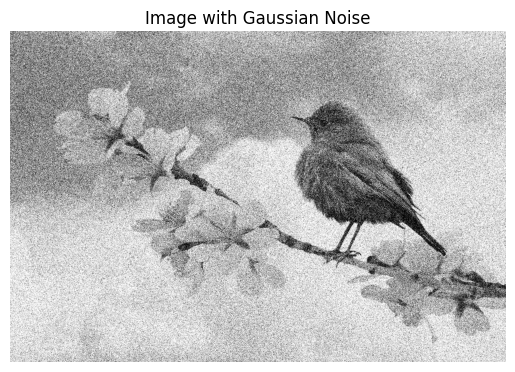

In [5]:
plt.imshow(img_noisy, cmap="gray")
plt.axis("off")
plt.title("Image with Gaussian Noise")
plt.show()

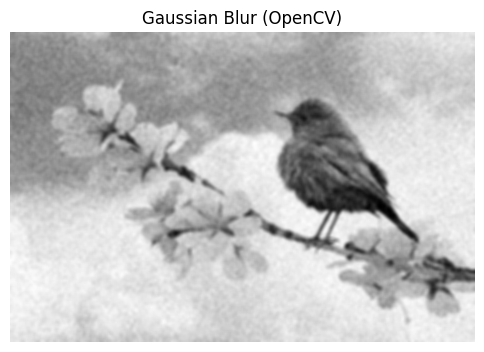

In [6]:
# Denoising using OpenCV's built-in Gaussian blur
opencv_result = cv2.GaussianBlur(img_noisy, (15, 15), 5)

plt.figure(figsize=(6, 6))
plt.imshow(opencv_result, cmap="gray")
plt.title("Gaussian Blur (OpenCV)")
plt.axis("off")
plt.show()

In [7]:
print("Original shape:", img_gray.shape)
print("Noisy shape:", img_noisy.shape)

Original shape: (853, 1280)
Noisy shape: (853, 1280)


In [8]:
def apply_gaussian_filter(src, ksize=7, sigma=2):
    half = ksize // 2

    # Build the Gaussian kernel
    xx, yy = np.mgrid[-half:half+1, -half:half+1]
    g_kernel = (1 / (2 * np.pi * sigma**2)) * np.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    g_kernel /= np.sum(g_kernel)

    # Pad the image so borders are handled properly
    padded_img = np.pad(src, ((half, half), (half, half)), mode='edge')

    h, w = src.shape
    result = np.zeros((h, w), dtype=np.float32)

    # Perform convolution manually
    for row in range(h):
        for col in range(w):
            patch = padded_img[row:row + ksize, col:col + ksize]
            result[row, col] = np.sum(patch * g_kernel)

    return np.clip(result, 0, 255).astype(np.uint8)

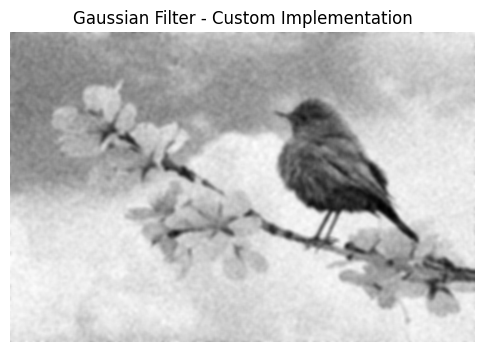

In [9]:
manual_result = apply_gaussian_filter(
    img_noisy,
    ksize=15,
    sigma=5
)

plt.figure(figsize=(6, 6))
plt.imshow(manual_result, cmap="gray")
plt.title("Gaussian Filter - Custom Implementation")
plt.axis("off")
plt.show()

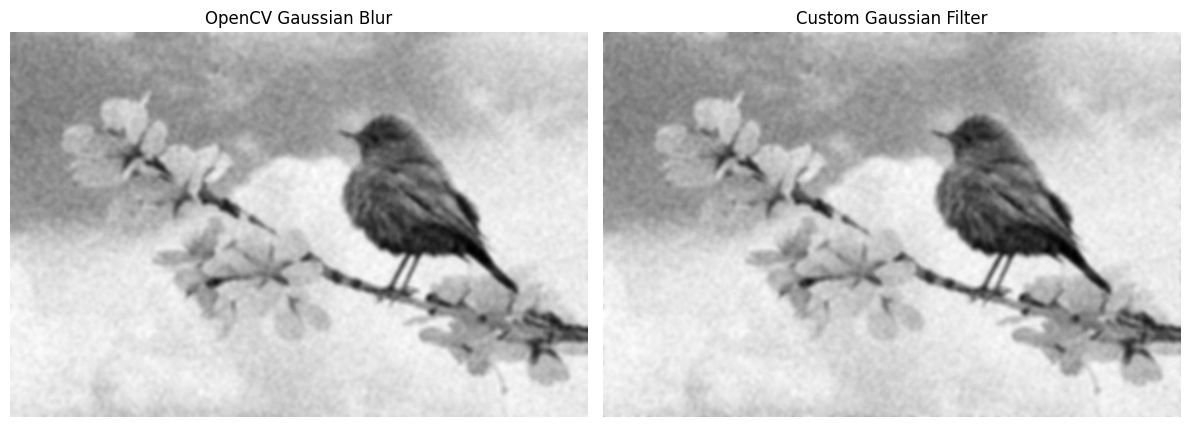

In [10]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(opencv_result, cmap="gray")
plt.title("OpenCV Gaussian Blur")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(manual_result, cmap="gray")
plt.title("Custom Gaussian Filter")
plt.axis("off")

plt.tight_layout()
plt.show()